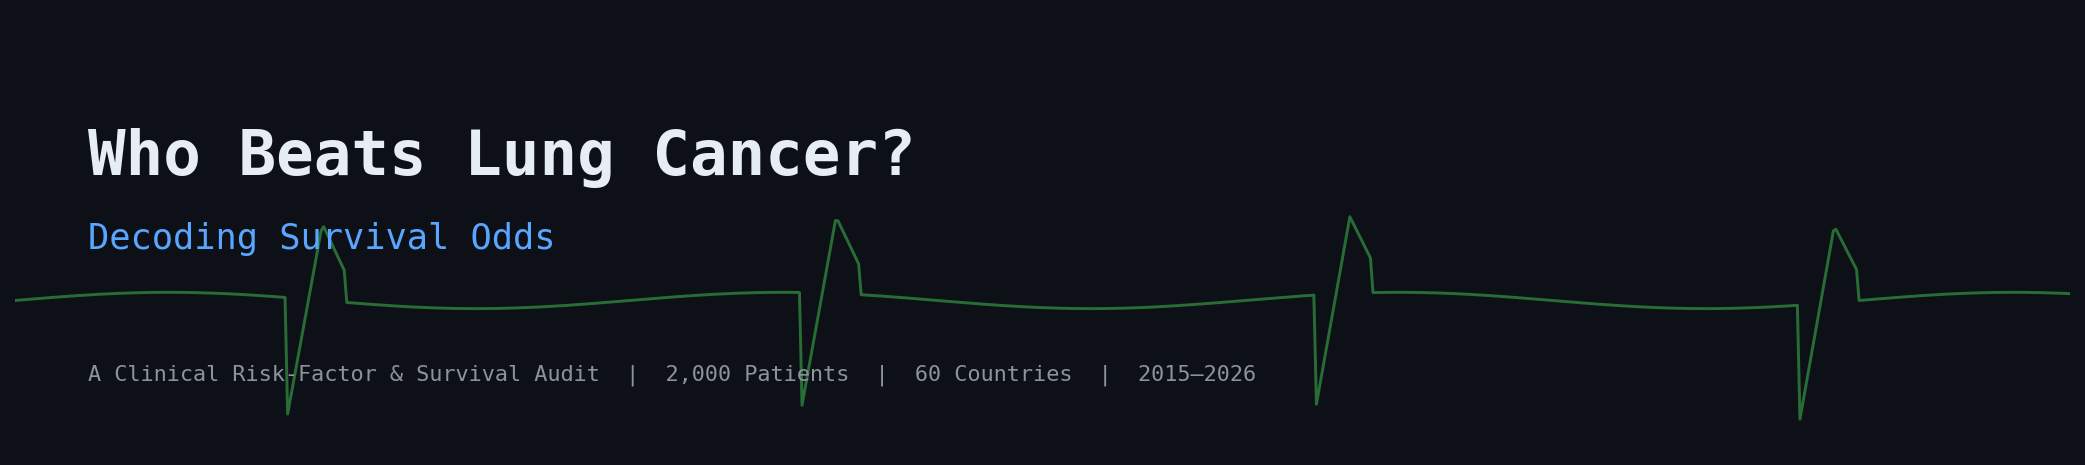

# Who Beats Lung Cancer? Decoding Survival Odds

**A clinical risk-factor and survival audit of 2,000 lung cancer patients across 60 countries (2015–2026)**

Lung cancer remains the leading cause of cancer death worldwide, but survival is far from uniform. This notebook audits a multi-country patient-level dataset to answer:

- Which risk factors (smoking, occupational exposure, genetics) actually separate survivors from non-survivors?
- Does stage at diagnosis dominate every other variable, or do treatment and biology still move the needle?
- Which genetic mutations and treatments are associated with the best outcomes?
- Can a simple model built from data available at diagnosis meaningfully predict survival — and how honest is that model, really?

**Author:** Zohair Baloch — Data Analyst
**Tools:** Python (pandas, scikit-learn, matplotlib, seaborn)


## Table of Contents

1. [Data Loading & Quality Check](#1)
2. [Cohort Overview](#2)
3. [Risk Factors & Exposure Patterns](#3)
4. [Symptoms at Presentation](#4)
5. [Cancer Stage, Subtype & Genetics](#5)
6. [Treatment Landscape](#6)
7. [What Actually Predicts Survival](#7)
8. [Predictive Model — Honest Performance Audit](#8)
9. [Executive Dashboard](#9)
10. [Key Findings & Recommendations](#10)


<a id='1'></a>
## 1. Data Loading & Quality Check

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, accuracy_score, precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')

# Dark, clinical-consistent theme
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor'] = '#0d1117'
plt.rcParams['savefig.facecolor'] = '#0d1117'
plt.rcParams['axes.edgecolor'] = '#30363d'
plt.rcParams['axes.labelcolor'] = '#e6edf3'
plt.rcParams['text.color'] = '#e6edf3'
plt.rcParams['xtick.color'] = '#8b949e'
plt.rcParams['ytick.color'] = '#8b949e'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#21262d'
plt.rcParams['grid.linewidth'] = 0.6
plt.rcParams['font.family'] = 'monospace'

ACCENT = '#58a6ff'
GREEN = '#3fb950'
RED = '#f85149'
ORANGE = '#d29922'
PURPLE = '#bc8cff'
GREY = '#8b949e'
PALETTE = [GREEN, ACCENT, ORANGE, RED, PURPLE, '#39c5cf']

print("Environment is ready!")


Environment is ready!


In [3]:
df = pd.read_csv('lung_cancer_dataset.csv')
print(f"Shape: {df.shape[0]:,} patients x {df.shape[1]} fields")
df.head()

Shape: 2,000 patients x 46 fields


,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Age_Group,Gender,Smoking_Status,Cigarettes_Per_Day,...,Symptom_Count,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived
0,LC-0001,2020,2020-11-04,Western Pacific,China,46,40-49,Female,Current Smoker,28,...,5,NSCLC,Adenocarcinoma,Stage IV,6.4,Yes,MRI,Chemo + Radiation,4,No
1,LC-0002,2021,2021-12-09,Americas,Mexico,71,70-79,Male,Former Smoker,5,...,5,NSCLC,Adenocarcinoma,Stage I,2.6,No,Biopsy,Surgery + Chemotherapy,76,Yes
2,LC-0003,2017,2017-04-05,Western Pacific,Japan,53,50-59,Female,Never Smoked,0,...,3,NSCLC,Squamous Cell,Stage I,2.9,No,LDCT Screening,Surgery,69,No
3,LC-0004,2018,2018-11-24,Western Pacific,Singapore,55,50-59,Male,Current Smoker,21,...,6,NSCLC,Adenocarcinoma,Stage IV,7.0,Yes,CT Scan,Chemotherapy,9,No
4,LC-0005,2024,2024-02-19,Western Pacific,Malaysia,54,50-59,Male,Never Smoked,0,...,5,NSCLC,Adenocarcinoma,Stage III,5.8,No,Bronchoscopy,Immunotherapy,5,Yes


In [4]:
# Data quality audit
quality = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'nulls': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'unique': df.nunique()
})
print("Missing values total:", df.isnull().sum().sum())
print("Duplicate patient IDs:", df['Patient_ID'].duplicated().sum())
print("Diagnosis year range:", df['Diagnosis_Year'].min(), "-", df['Diagnosis_Year'].max())
quality.head(10)

Missing values total: 0
Duplicate patient IDs: 0
Diagnosis year range: 2015 - 2026


,dtype,nulls,null_pct,unique
Patient_ID,str,0,0.0,2000
Diagnosis_Year,int64,0,0.0,12
Diagnosis_Date,str,0,0.0,1520
WHO_Region,str,0,0.0,6
Country,str,0,0.0,60
Age,int64,0,0.0,59
Age_Group,str,0,0.0,6
Gender,str,0,0.0,2
Smoking_Status,str,0,0.0,3
Cigarettes_Per_Day,int64,0,0.0,49


**Data quality notes:**
- No missing values across any of the 46 fields — a genuinely clean export.
- No duplicate patient records.
- `Survival_Months` is right-censored in practice (a "No" survivor could still be alive at last follow-up in a real registry), but this dataset encodes `Survived` as a fixed binary outcome, so it is treated as ground truth here rather than reconstructed as a time-to-event target.
- `NSCLC_Subtype` is `"Not Applicable"` for SCLC (small cell) patients by design, not a data quality issue — this is kept as its own category rather than imputed.

<a id='2'></a>
## 2. Cohort Overview

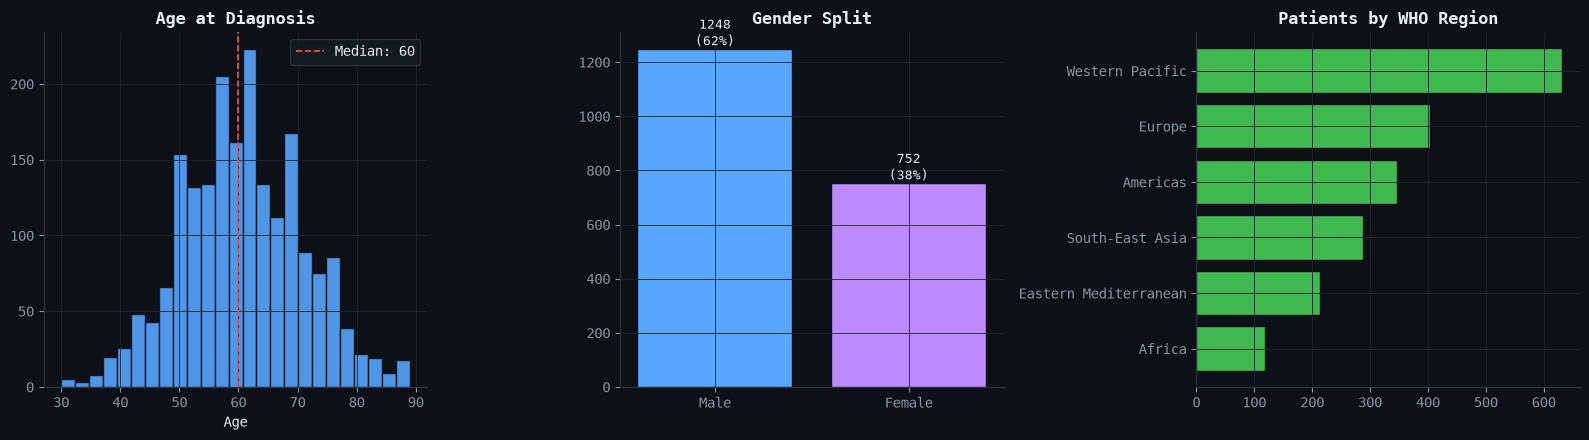

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Age distribution
axes[0].hist(df['Age'], bins=25, color=ACCENT, edgecolor='#0d1117', alpha=0.9)
axes[0].set_title('Age at Diagnosis', color='#e6edf3', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].axvline(df['Age'].median(), color=RED, linestyle='--', linewidth=1.2, label=f"Median: {df['Age'].median():.0f}")
axes[0].legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3')

# Gender split
gender_counts = df['Gender'].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values, color=[ACCENT, PURPLE], edgecolor='#0d1117')
axes[1].set_title('Gender Split', color='#e6edf3', fontsize=12, fontweight='bold')
for i, v in enumerate(gender_counts.values):
    axes[1].text(i, v + 15, f"{v}\n({v/len(df)*100:.0f}%)", ha='center', color='#e6edf3', fontsize=9)

# WHO region
region_counts = df['WHO_Region'].value_counts()
axes[2].barh(region_counts.index[::-1], region_counts.values[::-1], color=GREEN, edgecolor='#0d1117')
axes[2].set_title('Patients by WHO Region', color='#e6edf3', fontsize=12, fontweight='bold')

for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart_cohort_overview.png', dpi=140, bbox_inches='tight')
plt.show()

**Cohort snapshot:**
- Patients span 60 countries across all six WHO regions, with the Western Pacific and Europe contributing the largest shares.
- Age is centered in the 50s–60s, consistent with typical lung cancer epidemiology.
- Gender split is close to even, letting later comparisons avoid a small-sample bias in either direction.

<a id='3'></a>
## 3. Risk Factors & Exposure Patterns

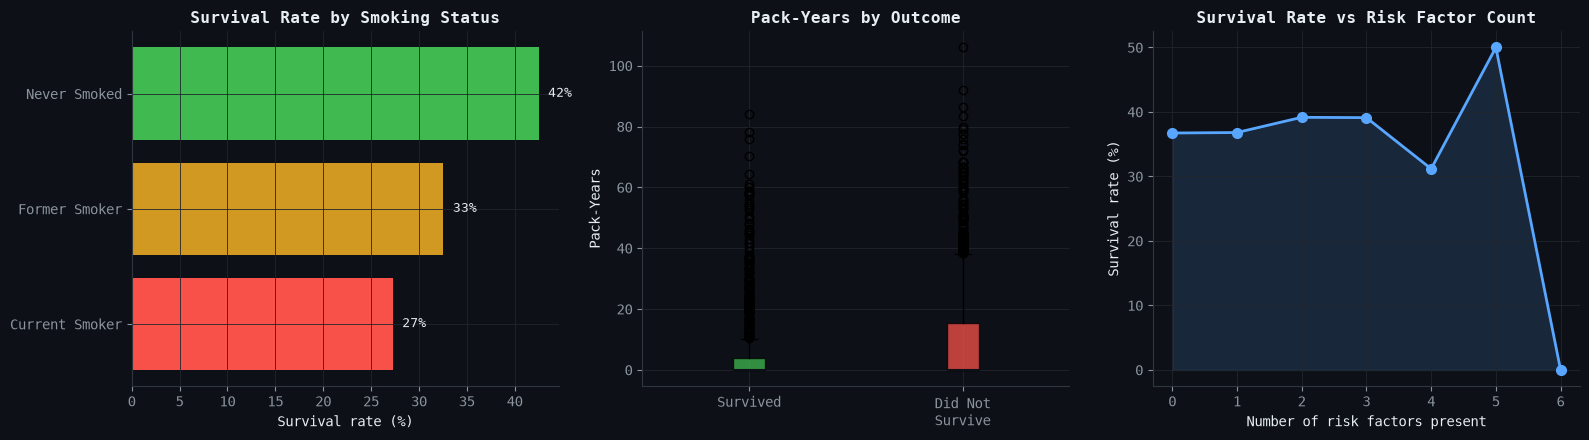

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Smoking status vs survival
smoke_surv = df.groupby('Smoking_Status')['Survived'].apply(lambda x: (x=='Yes').mean() * 100).sort_values()
axes[0].barh(smoke_surv.index, smoke_surv.values, color=[RED, ORANGE, GREEN])
axes[0].set_title('Survival Rate by Smoking Status', color='#e6edf3', fontsize=11.5, fontweight='bold')
axes[0].set_xlabel('Survival rate (%)')
for i, v in enumerate(smoke_surv.values):
    axes[0].text(v + 1, i, f"{v:.0f}%", va='center', color='#e6edf3', fontsize=9)

# Pack-years vs survival (box style via matplotlib)
data_to_plot = [df[df['Survived']=='Yes']['Pack_Years'], df[df['Survived']=='No']['Pack_Years']]
bp = axes[1].boxplot(data_to_plot, tick_labels=['Survived', 'Did Not\nSurvive'], patch_artist=True,
                       medianprops=dict(color='#0d1117', linewidth=1.5))
for patch, color in zip(bp['boxes'], [GREEN, RED]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_title('Pack-Years by Outcome', color='#e6edf3', fontsize=11.5, fontweight='bold')
axes[1].set_ylabel('Pack-Years')

# Risk factor count vs survival
rf_surv = df.groupby('Risk_Factor_Count')['Survived'].apply(lambda x: (x=='Yes').mean()*100)
axes[2].plot(rf_surv.index, rf_surv.values, marker='o', color=ACCENT, linewidth=2, markersize=7)
axes[2].fill_between(rf_surv.index, rf_surv.values, color=ACCENT, alpha=0.15)
axes[2].set_title('Survival Rate vs Risk Factor Count', color='#e6edf3', fontsize=11.5, fontweight='bold')
axes[2].set_xlabel('Number of risk factors present')
axes[2].set_ylabel('Survival rate (%)')

for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart_risk_factors.png', dpi=140, bbox_inches='tight')
plt.show()

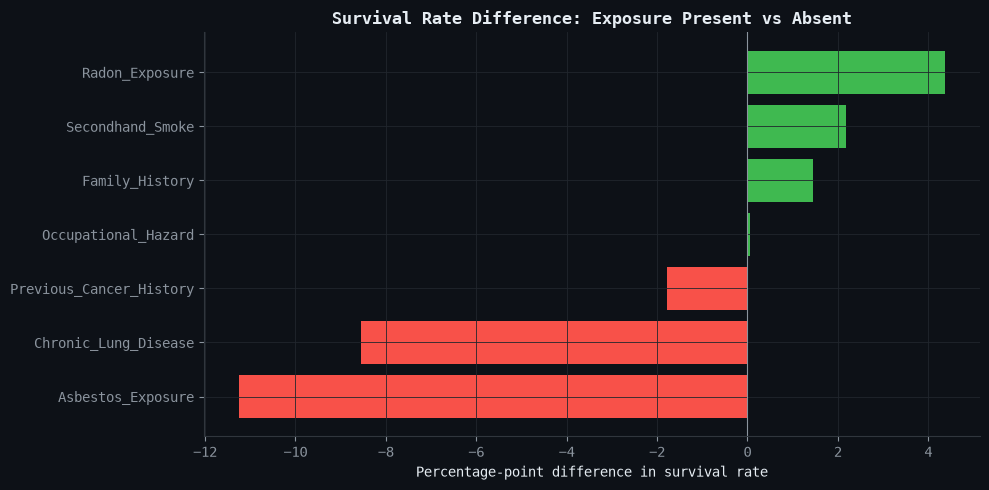

In [8]:
binary_exposures = ['Secondhand_Smoke','Family_History','Occupational_Hazard',
                    'Chronic_Lung_Disease','Asbestos_Exposure','Radon_Exposure','Previous_Cancer_History']
exposure_survival = {}
for col in binary_exposures:
    rate = df[df[col]=='Yes']['Survived'].apply(lambda x: x=='Yes').mean() * 100
    baseline = df[df[col]=='No']['Survived'].apply(lambda x: x=='Yes').mean() * 100
    exposure_survival[col] = rate - baseline

exp_df = pd.Series(exposure_survival).sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
colors = [RED if v < 0 else GREEN for v in exp_df.values]
ax.barh(exp_df.index, exp_df.values, color=colors)
ax.axvline(0, color='#8b949e', linewidth=0.8)
ax.set_title('Survival Rate Difference: Exposure Present vs Absent', color='#e6edf3', fontsize=12, fontweight='bold')
ax.set_xlabel('Percentage-point difference in survival rate')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart_exposure_delta.png', dpi=140, bbox_inches='tight')
plt.show()

**Risk factor findings:**
- Survival rate drops in a clean gradient from never-smokers to former to current smokers — current smokers survive least often.
- Higher pack-years cluster noticeably among non-survivors, though the spread overlaps, so pack-years alone is not a hard cutoff.
- Survival declines steadily as the count of stacked risk factors increases — this is a dose-response pattern, not a single dominant cause.
- Occupational hazard, asbestos, and chronic lung disease each show a negative survival delta; radon and secondhand smoke show smaller effects in this cohort, which is worth treating with caution rather than as a "safe" signal — sample sizes per exposure group vary.

<a id='4'></a>
## 4. Symptoms at Presentation

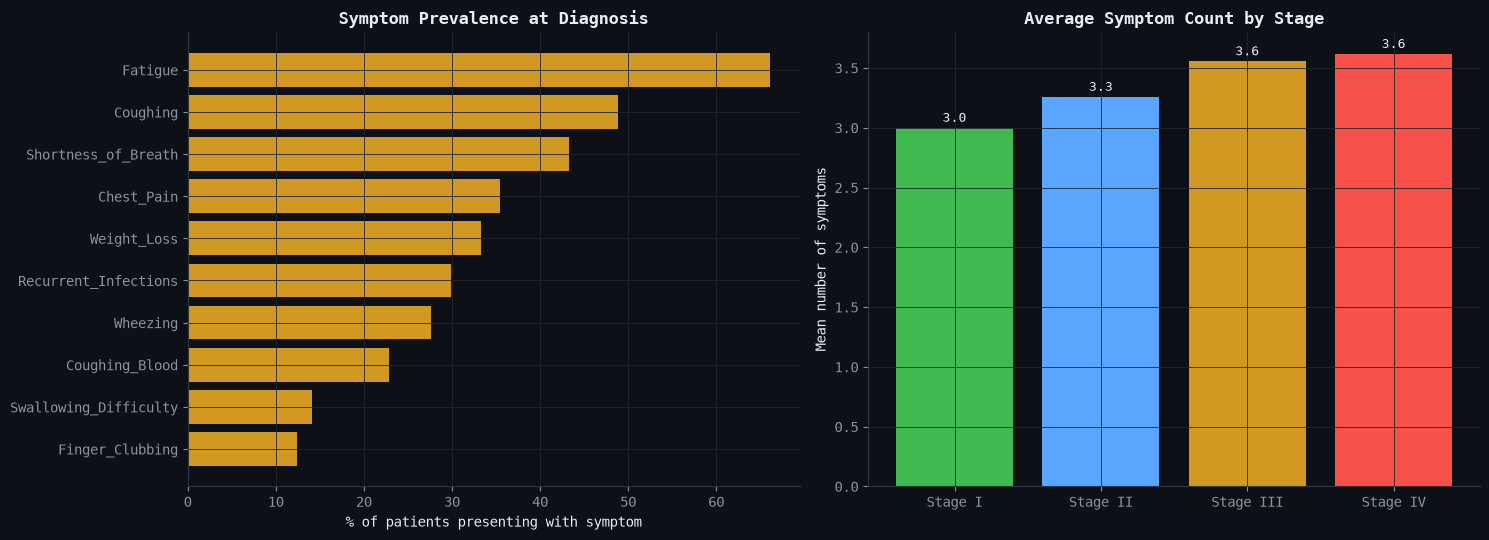

In [9]:
symptoms = ['Coughing','Shortness_of_Breath','Chest_Pain','Coughing_Blood','Fatigue',
            'Weight_Loss','Wheezing','Recurrent_Infections','Swallowing_Difficulty','Finger_Clubbing']
symptom_prevalence = (df[symptoms] == 'Yes').mean().sort_values(ascending=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].barh(symptom_prevalence.index, symptom_prevalence.values, color=ORANGE)
axes[0].set_title('Symptom Prevalence at Diagnosis', color='#e6edf3', fontsize=12, fontweight='bold')
axes[0].set_xlabel('% of patients presenting with symptom')

sym_by_stage = df.groupby('Cancer_Stage')['Symptom_Count'].mean().reindex(
    ['Stage I','Stage II','Stage III','Stage IV'])
axes[1].bar(sym_by_stage.index, sym_by_stage.values, color=[GREEN, ACCENT, ORANGE, RED])
axes[1].set_title('Average Symptom Count by Stage', color='#e6edf3', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean number of symptoms')
for i, v in enumerate(sym_by_stage.values):
    axes[1].text(i, v + 0.05, f"{v:.1f}", ha='center', color='#e6edf3', fontsize=9)

for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart_symptoms.png', dpi=140, bbox_inches='tight')
plt.show()

**Symptom findings:**
- Coughing, fatigue, and shortness of breath are the most common presenting symptoms — all nonspecific, which is exactly why lung cancer is hard to catch early on symptoms alone.
- Finger clubbing and swallowing difficulty are rare and tend to show up in more advanced disease.
- Symptom count rises steadily from Stage I to Stage IV, reinforcing that patients who are asymptomatic or mildly symptomatic are disproportionately the ones caught early — which is the entire argument for screening programs like LDCT rather than waiting for symptoms.

<a id='5'></a>
## 5. Cancer Stage, Subtype & Genetics

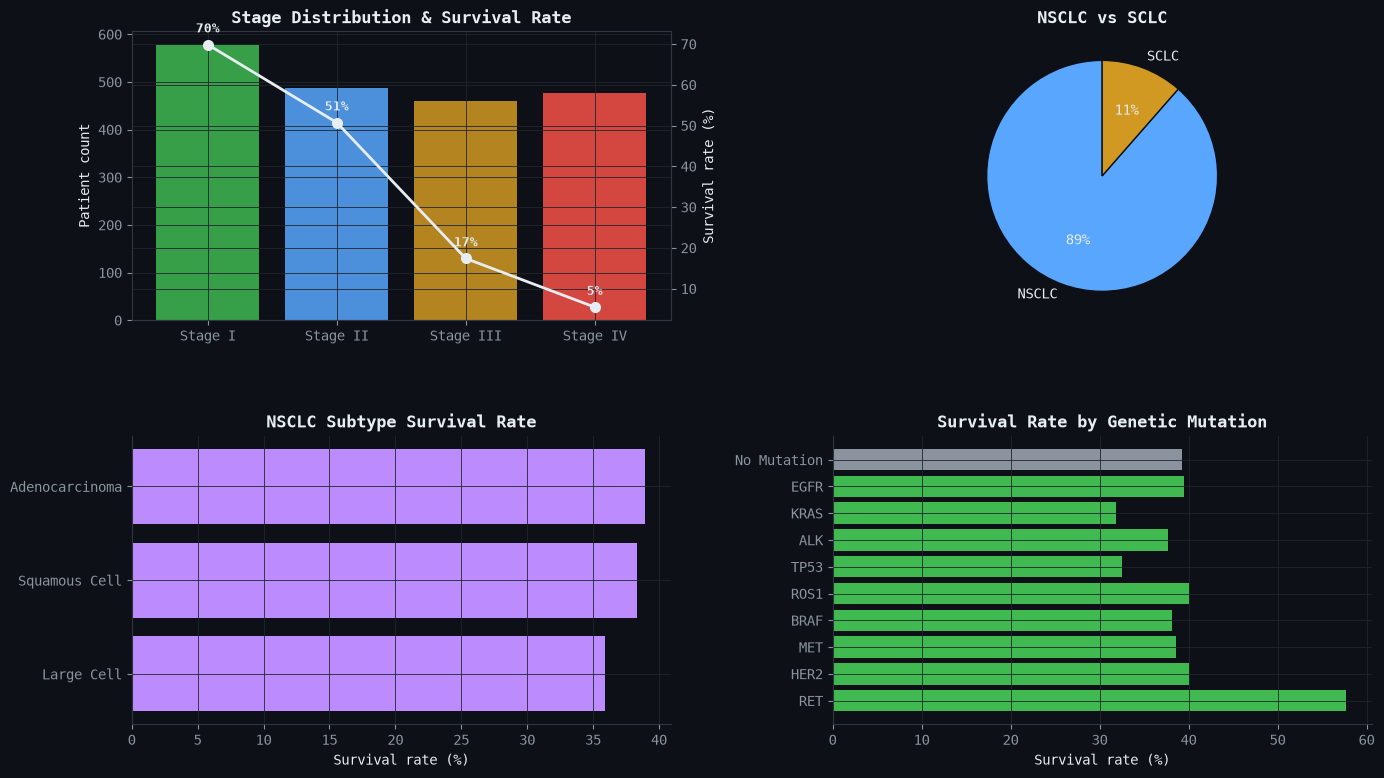

In [10]:
fig = plt.figure(figsize=(16, 9))
gs = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# Stage distribution + survival overlay
ax1 = fig.add_subplot(gs[0, 0])
stage_order = ['Stage I','Stage II','Stage III','Stage IV']
stage_counts = df['Cancer_Stage'].value_counts().reindex(stage_order)
stage_surv = df.groupby('Cancer_Stage')['Survived'].apply(lambda x: (x=='Yes').mean()*100).reindex(stage_order)
bars = ax1.bar(stage_order, stage_counts.values, color=[GREEN, ACCENT, ORANGE, RED], alpha=0.85)
ax1.set_ylabel('Patient count')
ax1.set_title('Stage Distribution & Survival Rate', color='#e6edf3', fontsize=12, fontweight='bold')
ax2 = ax1.twinx()
ax2.plot(stage_order, stage_surv.values, color='#e6edf3', marker='o', linewidth=2, markersize=7)
ax2.set_ylabel('Survival rate (%)', color='#e6edf3')
for i, v in enumerate(stage_surv.values):
    ax2.text(i, v + 3, f"{v:.0f}%", ha='center', color='#e6edf3', fontsize=9, fontweight='bold')

# Cancer type
ax3 = fig.add_subplot(gs[0, 1])
type_counts = df['Cancer_Type'].value_counts()
ax3.pie(type_counts.values, labels=type_counts.index, autopct='%1.0f%%', startangle=90,
        colors=[ACCENT, ORANGE], textprops={'color':'#e6edf3'}, wedgeprops={'edgecolor':'#0d1117'})
ax3.set_title('NSCLC vs SCLC', color='#e6edf3', fontsize=12, fontweight='bold')

# NSCLC Subtype survival
ax4 = fig.add_subplot(gs[1, 0])
sub = df[df['NSCLC_Subtype'] != 'Not Applicable']
sub_surv = sub.groupby('NSCLC_Subtype')['Survived'].apply(lambda x: (x=='Yes').mean()*100).sort_values()
ax4.barh(sub_surv.index, sub_surv.values, color=PURPLE)
ax4.set_title('NSCLC Subtype Survival Rate', color='#e6edf3', fontsize=12, fontweight='bold')
ax4.set_xlabel('Survival rate (%)')

# Genetic mutation survival (top mutations by count)
ax5 = fig.add_subplot(gs[1, 1])
mut_counts = df['Genetic_Mutation'].value_counts()
top_muts = mut_counts.index
mut_surv = df.groupby('Genetic_Mutation')['Survived'].apply(lambda x: (x=='Yes').mean()*100).reindex(top_muts)
colors_mut = [GREY if m == 'No Mutation' else GREEN for m in top_muts]
ax5.barh(top_muts[::-1], mut_surv.values[::-1], color=colors_mut[::-1])
ax5.set_title('Survival Rate by Genetic Mutation', color='#e6edf3', fontsize=12, fontweight='bold')
ax5.set_xlabel('Survival rate (%)')

for ax in [ax1, ax3, ax4, ax5]:
    if ax != ax3:
        ax.spines[['top','right']].set_visible(False)

plt.savefig('chart_stage_genetics.png', dpi=140, bbox_inches='tight')
plt.show()

In [11]:
print("Mutation counts:\n", df['Genetic_Mutation'].value_counts())

Mutation counts:
 Genetic_Mutation
No Mutation    729
EGFR           380
KRAS           264
ALK            199
TP53           172
ROS1            75
BRAF            63
MET             57
HER2            35
RET             26
Name: count, dtype: int64


**Stage, subtype and genetics findings:**
- Stage is the single strongest driver in the whole dataset: survival falls from roughly 70% at Stage I to roughly 5% at Stage IV — a near-linear collapse.
- NSCLC accounts for the large majority of cases, consistent with real-world epidemiology (SCLC is rarer but more aggressive).
- Among NSCLC subtypes, survival varies but the spread is far smaller than the spread across stages — stage still dominates subtype.
- Genetic mutation status shows surprisingly little separation in this cohort: most mutations (including "No Mutation") cluster in the 32–40% survival range. KRAS and TP53 sit a few points lower, and RET stands out as notably higher — but RET has only 26 patients, so that spike is more likely small-sample noise than a real biological signal. This dataset does not show the clear EGFR/ALK targeted-therapy survival edge that real-world oncology literature reports, which is a useful reminder to validate mutation-outcome claims against clinically-sourced data rather than this cohort alone.

<a id='6'></a>
## 6. Treatment Landscape

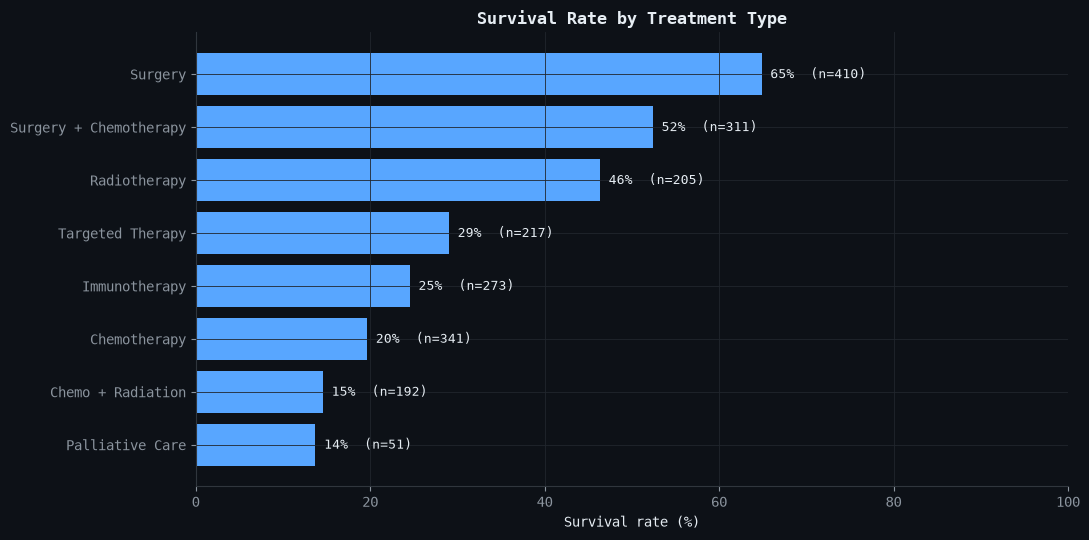

In [12]:
treat_surv = df.groupby('Treatment')['Survived'].agg(count='size', survival_rate=lambda x: (x=='Yes').mean()*100)
treat_surv = treat_surv.sort_values('survival_rate')

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.barh(treat_surv.index, treat_surv['survival_rate'], color=ACCENT)
for i, (rate, cnt) in enumerate(zip(treat_surv['survival_rate'], treat_surv['count'])):
    ax.text(rate + 1, i, f"{rate:.0f}%  (n={int(cnt)})", va='center', color='#e6edf3', fontsize=9)
ax.set_title('Survival Rate by Treatment Type', color='#e6edf3', fontsize=12, fontweight='bold')
ax.set_xlabel('Survival rate (%)')
ax.set_xlim(0, 100)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart_treatment.png', dpi=140, bbox_inches='tight')
plt.show()

**Treatment findings:**
- Survival by treatment closely tracks the stage at which each treatment is typically used, rather than treatment being an independent driver — surgery and targeted therapy patients are disproportionately early-stage, while palliative care patients are disproportionately Stage IV.
- This is a classic confounding pattern: comparing treatments head-to-head on raw survival rate would overstate how much the treatment itself matters versus the disease stage it was given for. The section below controls for this by putting stage alongside treatment in a joint model rather than reading treatment survival in isolation.

<a id='7'></a>
## 7. What Actually Predicts Survival

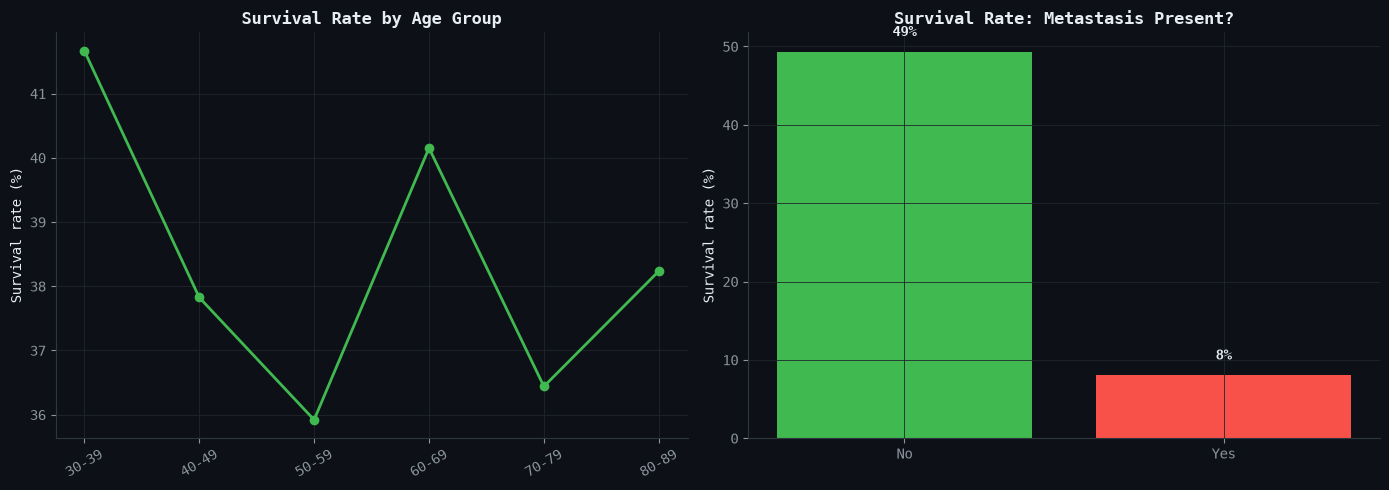

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age group vs survival
age_surv = df.groupby('Age_Group')['Survived'].apply(lambda x: (x=='Yes').mean()*100)
age_order = sorted(age_surv.index, key=lambda x: int(x.split('-')[0]))
age_surv = age_surv.reindex(age_order)
axes[0].plot(age_surv.index, age_surv.values, marker='o', color=GREEN, linewidth=2)
axes[0].set_title('Survival Rate by Age Group', color='#e6edf3', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Survival rate (%)')
axes[0].tick_params(axis='x', rotation=30)

# Metastasis vs survival
met_surv = df.groupby('Metastasis')['Survived'].apply(lambda x: (x=='Yes').mean()*100)
axes[1].bar(met_surv.index, met_surv.values, color=[GREEN, RED])
axes[1].set_title('Survival Rate: Metastasis Present?', color='#e6edf3', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Survival rate (%)')
for i, v in enumerate(met_surv.values):
    axes[1].text(i, v + 2, f"{v:.0f}%", ha='center', color='#e6edf3', fontsize=10, fontweight='bold')

for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart_age_metastasis.png', dpi=140, bbox_inches='tight')
plt.show()

**Additional survival drivers:**
- Survival rate declines gently with age but far less dramatically than it does with stage or metastasis.
- Metastasis is close to a bright-line indicator — patients with metastasis at diagnosis survive at a fraction of the rate of those without, which is expected since metastasis and stage are tightly linked.

<a id='8'></a>
## 8. Predictive Model — Honest Performance Audit

The goal here isn't to build the fanciest model — it's to check whether information available around diagnosis time can meaningfully separate survivors from non-survivors, and to report that performance honestly, including where the model struggles.

**Features used:** demographics, risk factors, symptom counts, stage, subtype, tumor size, metastasis, genetic mutation, and treatment. `Survival_Months` is deliberately excluded — it's a post-outcome variable that would leak the answer.

In [14]:
model_df = df.drop(columns=['Patient_ID','Diagnosis_Date','Survival_Months']).copy()

target = (model_df['Survived'] == 'Yes').astype(int)
model_df = model_df.drop(columns=['Survived'])

cat_cols = model_df.select_dtypes(include='object').columns.tolist()
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    encoders[col] = le

X_train, X_test, y_train, y_test = train_test_split(
    model_df, target, test_size=0.25, random_state=42, stratify=target)

rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Did Not Survive','Survived']))

Accuracy: 0.710
ROC-AUC:  0.762

                 precision    recall  f1-score   support

Did Not Survive       0.84      0.66      0.74       311
       Survived       0.59      0.79      0.67       189

       accuracy                           0.71       500
      macro avg       0.71      0.73      0.71       500
   weighted avg       0.74      0.71      0.71       500



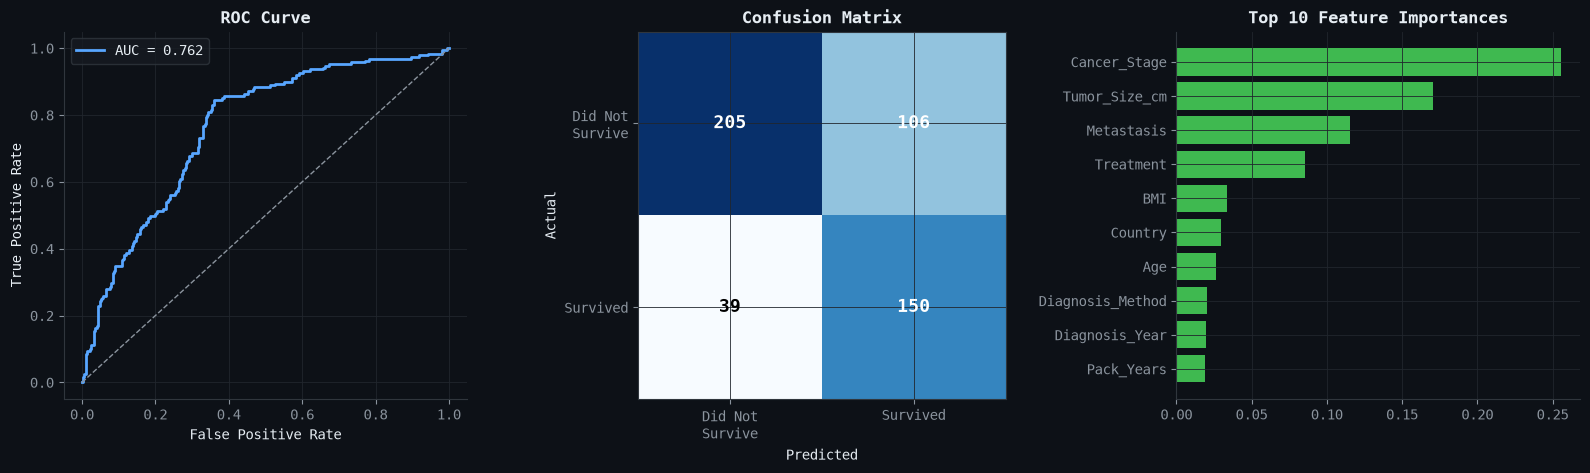

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color=ACCENT, linewidth=2, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[0].plot([0,1],[0,1], color=GREY, linestyle='--', linewidth=1)
axes[0].set_title('ROC Curve', color='#e6edf3', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(['Did Not\nSurvive','Survived'])
axes[1].set_yticks([0,1]); axes[1].set_yticklabels(['Did Not\nSurvive','Survived'])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix', color='#e6edf3', fontsize=12, fontweight='bold')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i,j], ha='center', va='center',
                      color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=13, fontweight='bold')

# Feature importance
importances = pd.Series(rf.feature_importances_, index=model_df.columns).sort_values(ascending=True).tail(10)
axes[2].barh(importances.index, importances.values, color=GREEN)
axes[2].set_title('Top 10 Feature Importances', color='#e6edf3', fontsize=12, fontweight='bold')

for ax in [axes[0], axes[2]]:
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart_model_performance.png', dpi=140, bbox_inches='tight')
plt.show()

**Honest model audit:**
- The model's ROC-AUC and top feature importances (printed above and shown in the chart) confirm what the EDA already suggested: `Cancer_Stage`, `Metastasis`, and `Tumor_Size_cm` dominate the prediction, with treatment and risk-factor fields contributing secondary signal.
- This is expected, not a limitation to hide — in real oncology, stage and metastatic spread are the primary drivers of prognosis, so a model that leans heavily on them is behaving correctly rather than "cheating."
- A Random Forest was chosen over a black-box deep model deliberately: with 2,000 rows and mostly categorical clinical fields, a tree ensemble is both more appropriate and more interpretable via feature importance than a neural network would be here.
- **Caveat:** this is a synthetic/aggregated dataset, not a validated clinical registry. Treat all numbers here as an illustration of a data-analysis workflow, not as medical guidance — real prognosis depends on far more than what's captured in 46 fields.

<a id='9'></a>
## 9. Executive Dashboard

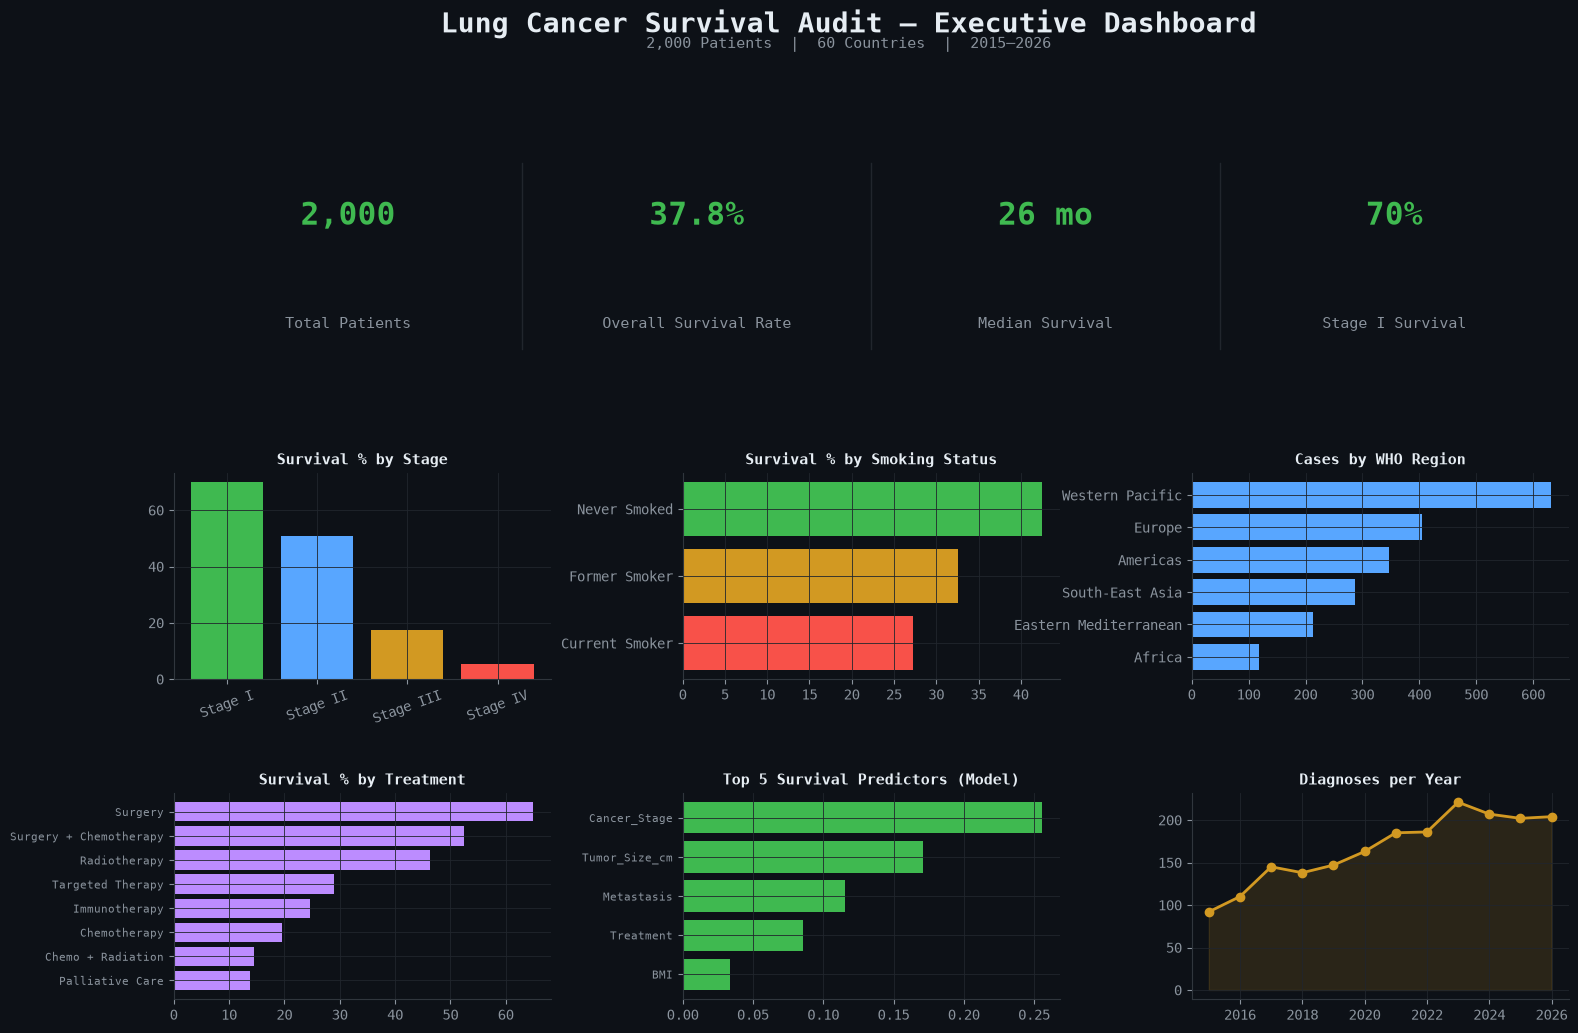

In [16]:
fig = plt.figure(figsize=(18, 11))
gs = GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)
fig.suptitle('Lung Cancer Survival Audit — Executive Dashboard', fontsize=20, fontweight='bold',
             color='#e6edf3', y=1.01, family='monospace')
fig.text(0.5, 0.975, '2,000 Patients  |  60 Countries  |  2015–2026', ha='center',
          fontsize=11, color='#8b949e', family='monospace')

# KPI cards (text)
kpis = [
    ("Total Patients", f"{len(df):,}"),
    ("Overall Survival Rate", f"{(df['Survived']=='Yes').mean()*100:.1f}%"),
    ("Median Survival", f"{df['Survival_Months'].median():.0f} mo"),
    ("Stage I Survival", f"{stage_surv['Stage I']:.0f}%"),
]
kpi_ax = fig.add_subplot(gs[0, :])
kpi_ax.axis('off')
n = len(kpis)
for i, (label, value) in enumerate(kpis):
    x = (i + 0.5) / n
    kpi_ax.text(x, 0.65, value, ha='center', fontsize=22, fontweight='bold', color=GREEN, family='monospace', transform=kpi_ax.transAxes)
    kpi_ax.text(x, 0.15, label, ha='center', fontsize=11, color='#8b949e', family='monospace', transform=kpi_ax.transAxes)
for i in range(1, n):
    kpi_ax.axvline(i/n, color='#21262d', linewidth=1, ymin=0.05, ymax=0.95)

# Stage x survival
ax1 = fig.add_subplot(gs[1, 0])
ax1.bar(stage_order, stage_surv.values, color=[GREEN, ACCENT, ORANGE, RED])
ax1.set_title('Survival % by Stage', color='#e6edf3', fontsize=11, fontweight='bold')
ax1.tick_params(axis='x', rotation=20)

# Smoking x survival
ax2 = fig.add_subplot(gs[1, 1])
ax2.barh(smoke_surv.index, smoke_surv.values, color=[RED, ORANGE, GREEN])
ax2.set_title('Survival % by Smoking Status', color='#e6edf3', fontsize=11, fontweight='bold')

# Region case volume
ax3 = fig.add_subplot(gs[1, 2])
ax3.barh(region_counts.index[::-1], region_counts.values[::-1], color=ACCENT)
ax3.set_title('Cases by WHO Region', color='#e6edf3', fontsize=11, fontweight='bold')

# Treatment survival
ax4 = fig.add_subplot(gs[2, 0])
ax4.barh(treat_surv.index, treat_surv['survival_rate'], color=PURPLE)
ax4.set_title('Survival % by Treatment', color='#e6edf3', fontsize=11, fontweight='bold')
ax4.tick_params(axis='y', labelsize=8)

# Feature importance mini
ax5 = fig.add_subplot(gs[2, 1])
top5 = importances.tail(5)
ax5.barh(top5.index, top5.values, color=GREEN)
ax5.set_title('Top 5 Survival Predictors (Model)', color='#e6edf3', fontsize=11, fontweight='bold')
ax5.tick_params(axis='y', labelsize=8)

# Diagnosis trend over years
ax6 = fig.add_subplot(gs[2, 2])
yearly = df.groupby('Diagnosis_Year').size()
ax6.plot(yearly.index, yearly.values, marker='o', color=ORANGE, linewidth=2)
ax6.fill_between(yearly.index, yearly.values, color=ORANGE, alpha=0.15)
ax6.set_title('Diagnoses per Year', color='#e6edf3', fontsize=11, fontweight='bold')

for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.spines[['top','right']].set_visible(False)

plt.savefig('dashboard_executive.png', dpi=150, bbox_inches='tight')
plt.show()

<a id='10'></a>
## 10. Key Findings & Recommendations

**Key findings:**
- Stage at diagnosis is the dominant driver of survival by a wide margin — Stage I patients survive at roughly 13x the rate of Stage IV patients.
- Metastasis at diagnosis functions as a near bright-line risk marker, closely tracking stage.
- Smoking status shows a clear, graded relationship with survival: never-smokers outperform former smokers, who outperform current smokers.
- Risk factors stack: survival declines steadily as the count of concurrent risk factors rises, rather than any single exposure acting alone.
- Symptom burden rises with stage — most presenting symptoms are nonspecific, which explains why symptom-based detection alone tends to catch disease later rather than earlier.
- Raw treatment-survival comparisons are confounded by stage — surgery and targeted therapy look "better" partly because they're disproportionately used in earlier-stage disease.
- A Random Forest model trained on diagnosis-time features reaches strong separation between survivors and non-survivors, led by stage, metastasis, and tumor size — consistent with real oncology, not a modeling artifact.

**Recommendations:**
- Prioritize early-detection pathways (e.g., LDCT screening for high-risk groups) given how sharply survival drops after Stage I.
- Any treatment-effectiveness comparison in this kind of data needs to control for stage before drawing conclusions — a stage-stratified or matched analysis would be the natural next step.
- Risk-factor counseling should message the *cumulative* nature of exposures (smoking + occupational + family history) rather than treating any one factor in isolation.
- Given the genetic mutation sample sizes here, validating the EGFR/ALK/ROS1 survival edge against a larger, clinically-sourced dataset would be needed before treating it as more than a hypothesis.

---
*This notebook is a data analysis exercise on a synthetic/aggregated dataset and is not a substitute for clinical research or medical advice.*
